#Fase 1: Dataset Adult

**Materia:** Introducción a la Inteligencia Artificial  
**Dataset:** Adult / Census Income
**Objetivo:** Predecir si una persona gana más o menos de 50K USD al año.

Este notebook cubre:
- Análisis gráfico (distribuciones y correlaciones)
- Preprocesamiento (nulos, dummificación, normalización, outliers)
- Construcción del dataset de trabajo (train/test split)

## 1. Importar librerías

In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y partición
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Estilo de los gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Cargar el dataset

El dataset original no trae los nombres de las columnas, así que se los ponemos manualmente.  
Cargamos `adult.data` y `adult.test` y los unimos en un solo DataFrame.

In [ ]:
# Nombres de las columnas (sacados de adult.names)
columnas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Rutas locales (archivos descargados del repositorio UCI)
ruta_train = 'adult.data'
ruta_test  = 'adult.test'

# Cargar archivo de entrenamiento
df_train = pd.read_csv(ruta_train, names=columnas, sep=',', skipinitialspace=True)

# El archivo de test
df_test = pd.read_csv(ruta_test, names=columnas, sep=',', skipinitialspace=True, skiprows=1)
df_test['income'] = df_test['income'].str.replace('.', '', regex=False)

# Unir ambos archivos
df = pd.concat([df_train, df_test], ignore_index=True)

df.head()

## 3. Información básica del dataset

In [ ]:
# Tipos de datos y conteo de no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
# Estadísticas de las variables numéricas
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Estadísticas de las variables categóricas
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


## 4. Análisis gráfico (EDA)

### 4.1 Distribución de la variable objetivo (income)

/tmp/ipykernel_16243/1479991885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='income', palette='Set2')


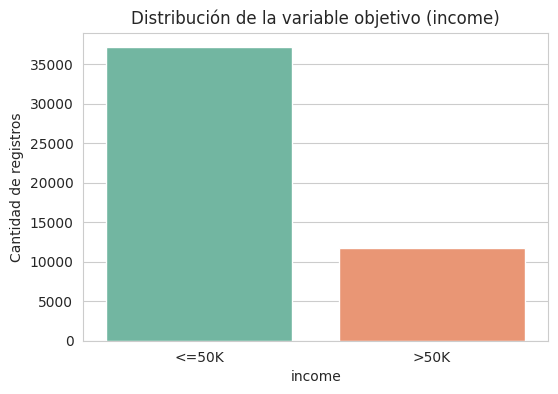

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


In [ ]:
# Conteo de cada clase de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='income', palette='Set2')
plt.title('Distribución de la variable objetivo (income)')
plt.ylabel('Cantidad de registros')
plt.show()

# Porcentaje de cada clase
print(df['income'].value_counts(normalize=True) * 100)

### 4.2 Distribución de variables numéricas

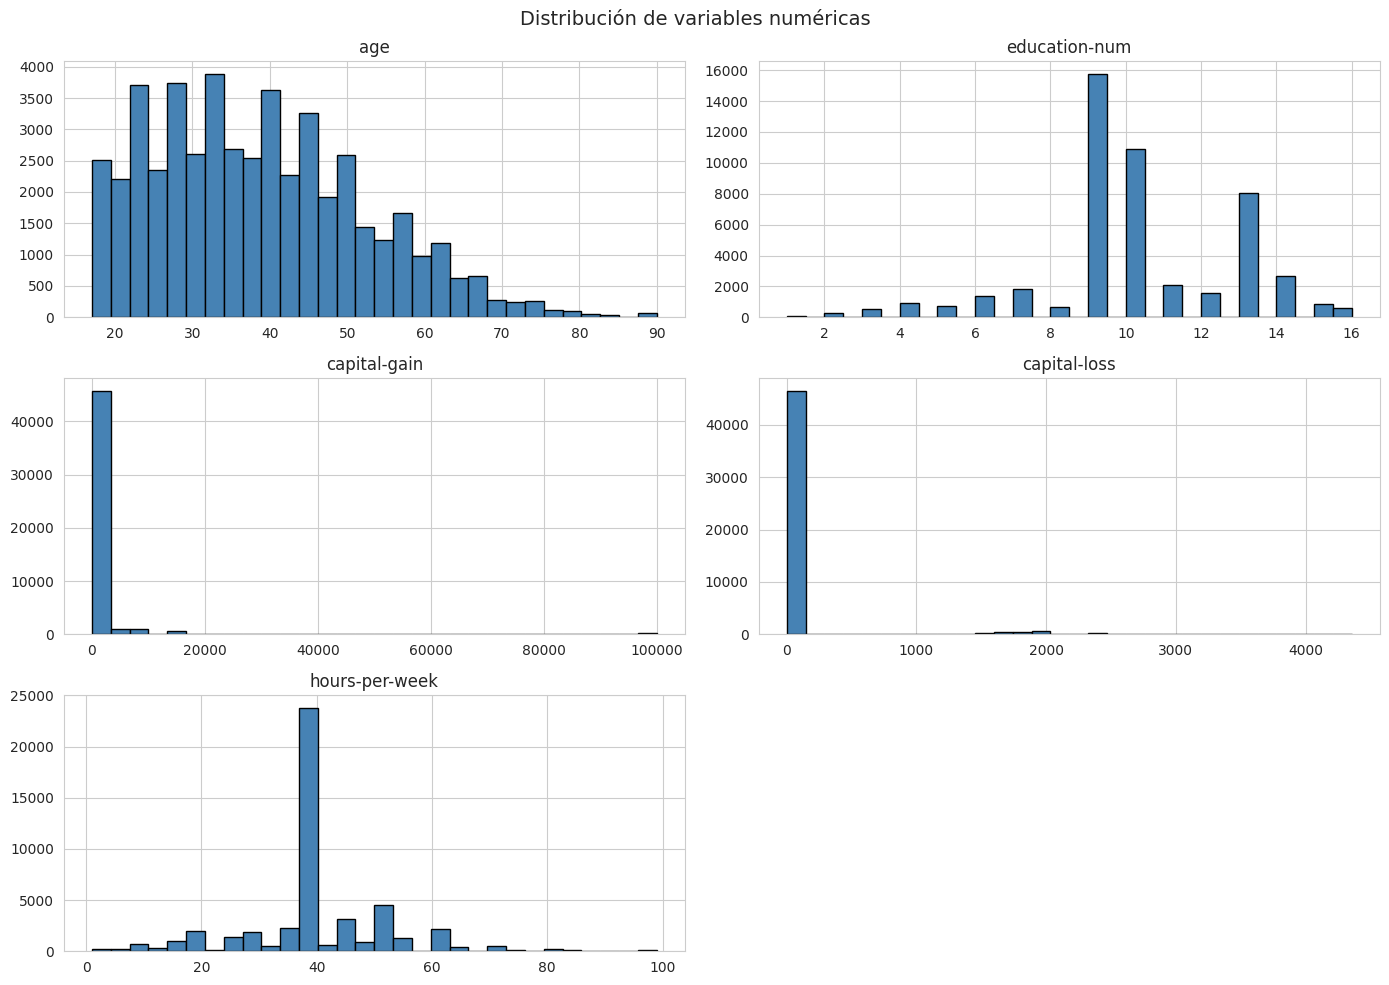

In [ ]:
# Histogramas de todas las variables numéricas
variables_numericas = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

df[variables_numericas].hist(bins=30, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Boxplots para detectar outliers visualmente

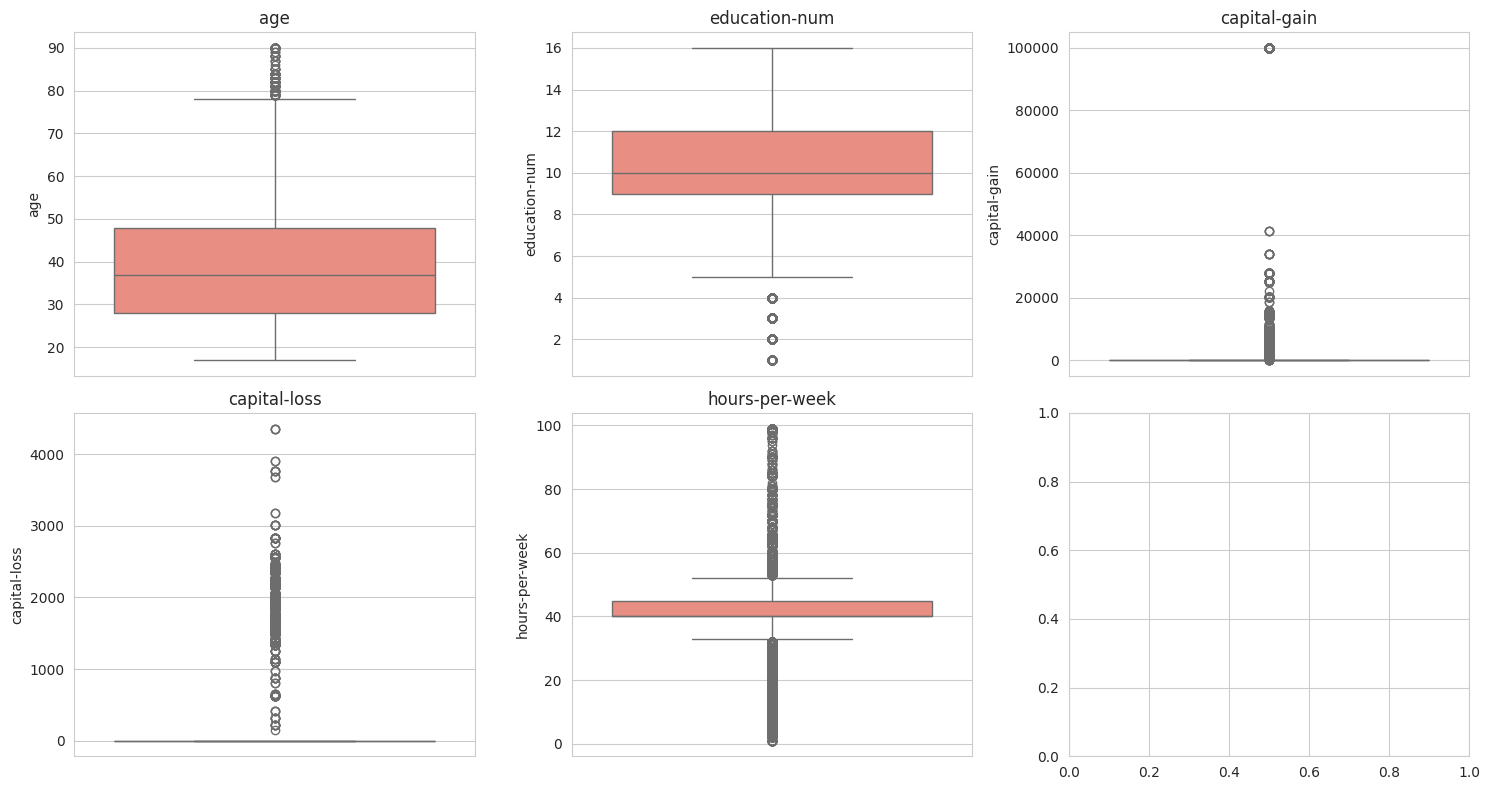

In [ ]:
# Boxplots de las variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), variables_numericas):
    sns.boxplot(data=df, y=col, ax=ax, color='salmon')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 4.4 Variables categóricas vs income

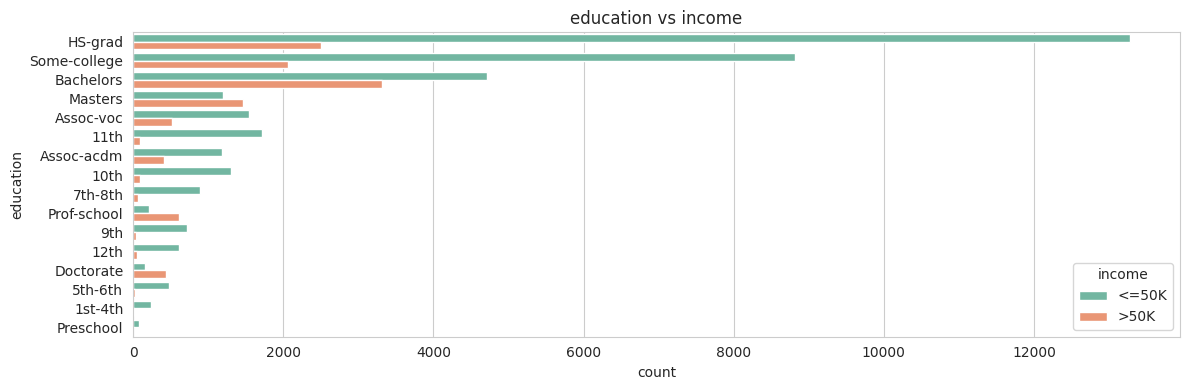

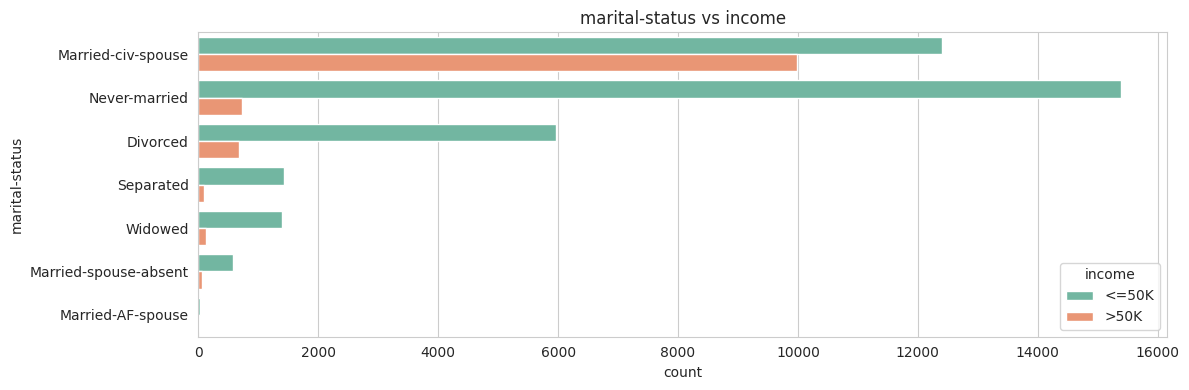

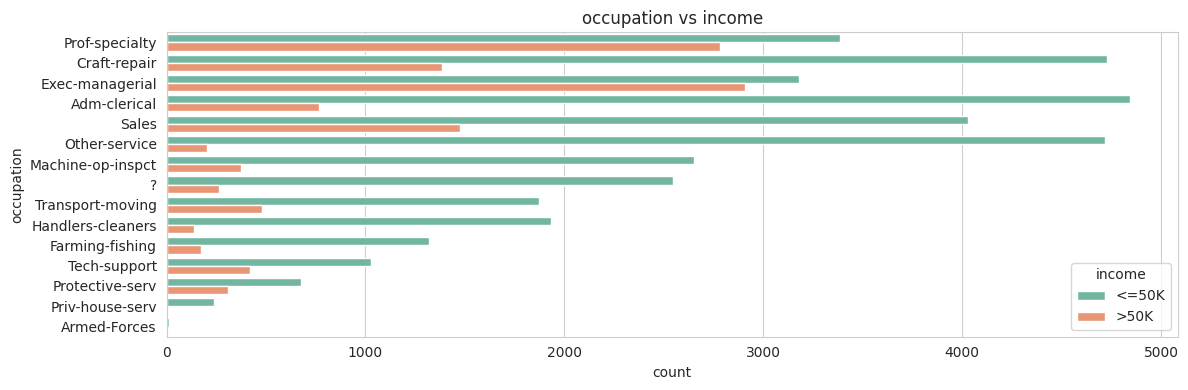

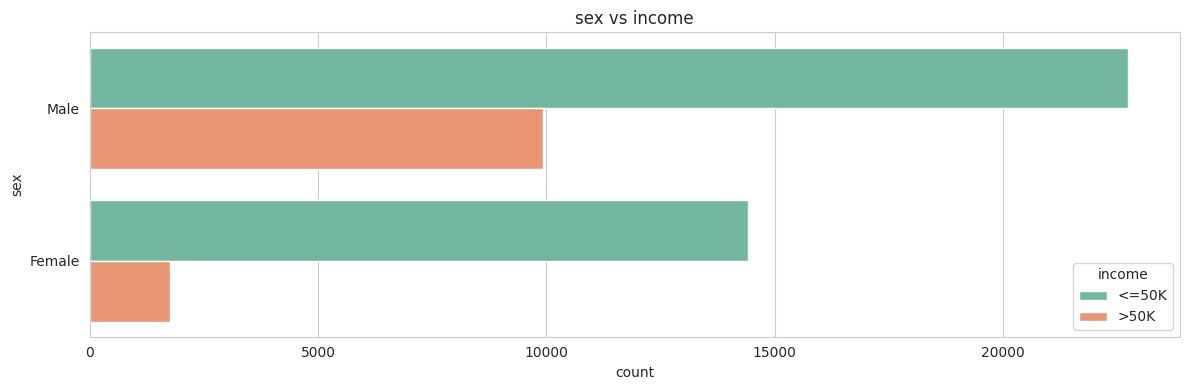

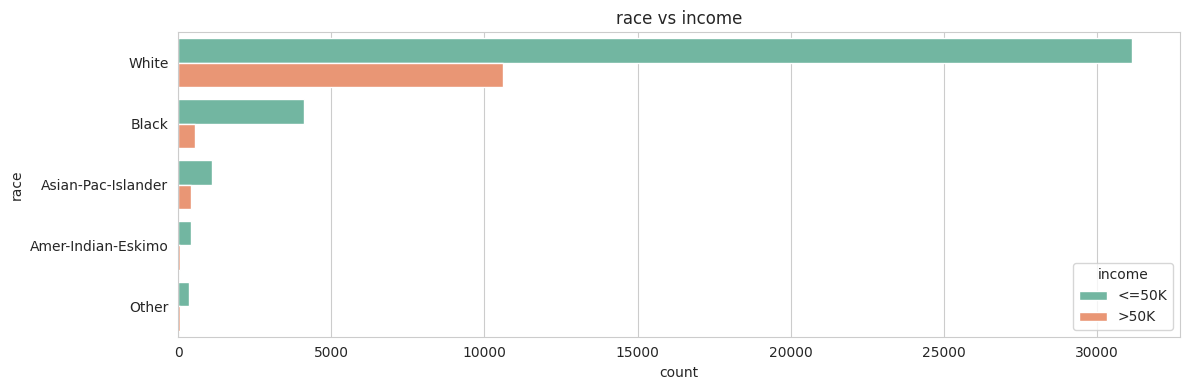

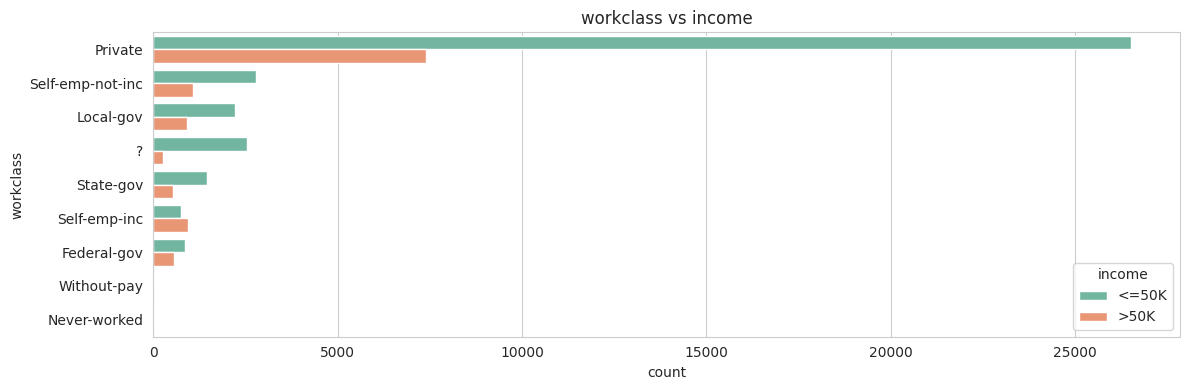

In [ ]:
# Algunas categóricas más interesantes para comparar contra el income
categoricas_a_revisar = ['education', 'marital-status', 'occupation', 'sex', 'race', 'workclass']

for col in categoricas_a_revisar:
    plt.figure(figsize=(12, 4))
    sns.countplot(data=df, y=col, hue='income', palette='Set2',
                  order=df[col].value_counts().index)
    plt.title(f'{col} vs income')
    plt.tight_layout()
    plt.show()

### 4.5 Matriz de correlación (variables numéricas)

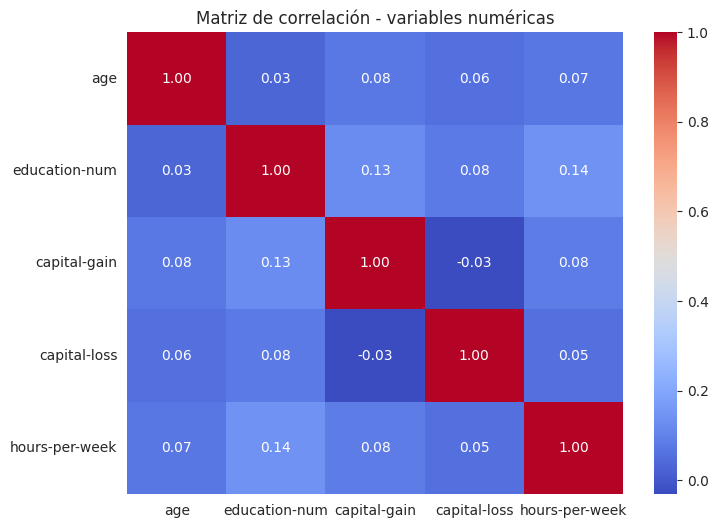

In [ ]:
# Mapa de calor con las correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(df[variables_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación - variables numéricas')
plt.show()

## 5. Preprocesamiento

### 5.1 Tratamiento de valores nulos

En este dataset los valores faltantes vienen marcados como `'?'` en lugar de NaN, hay que convertirlos primero.

In [ ]:
# Reemplazar '?' por NaN para que pandas los detecte como nulos
df = df.replace('?', np.nan)

# Ver cuántos nulos hay por columna
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0])
print(f'\nPorcentaje de filas con al menos un nulo: {df.isnull().any(axis=1).mean()*100:.2f}%')

In [ ]:
# Imputar nulos con la moda (valor más frecuente) en las 3 columnas categóricas afectadas
for col in ['workclass', 'occupation', 'native-country']:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)

# Verificar que ya no hay nulos
print('Nulos después de imputar:', df.isnull().sum().sum())

### 5.2 Búsqueda y manejo de outliers

Lo hacemos **antes** de la dummificación y normalización para no perder información del análisis estadístico original.  
Usamos el método del **rango intercuartílico (IQR)**.

In [ ]:
# Función para contar outliers usando IQR
def contar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return outliers, lim_inf, lim_sup

# Revisar outliers en cada variable numérica
print('Outliers detectados por IQR:')
for col in variables_numericas:
    n, low, high = contar_outliers_iqr(df[col])
    print(f'  {col:18s} -> {n:5d} outliers  (límites: {low:.1f}, {high:.1f})')

In [ ]:
# Aplicamos winsorización (recortar valores extremos) solo a 'age' y 'hours-per-week'.
# capital-gain y capital-loss los dejamos así porque sus ceros son legítimos (la mayoría no tiene).
# fnlwgt es un peso censal, sus extremos también son válidos.

for col in ['age', 'hours-per-week']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

print('Outliers tratados con winsorización (clip) en age y hours-per-week.')
print(f'Filas conservadas: {len(df)}')

### 5.3 Codificación de la variable objetivo

In [ ]:
# Convertir income en 0 (<=50K) y 1 (>50K)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
df['income'].value_counts()

### 5.4 Dummificación de variables categóricas

Quitamos la columna `education` porque ya tenemos `education-num` (es la misma información en numérico).

In [ ]:
# Eliminar education (redundante con education-num)
df = df.drop(columns=['education'])

# Lista de columnas categóricas restantes
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship',
            'race', 'sex', 'native-country']

# One-hot encoding (drop_first=True para evitar multicolinealidad)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Forma después de dummificar: {df.shape}')
df.head()

### 5.5 Normalización de variables numéricas

Usamos `StandardScaler` (media 0 y desviación estándar 1).

In [ ]:
# Las variables a normalizar (las numéricas originales, sin la objetivo)
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].describe().round(3)

## 6. Construcción del dataset de trabajo

Separamos en **entrenamiento (80%)** y **pruebas (20%)**.  
Usamos `stratify=y` para mantener la misma proporción de clases en ambos conjuntos (la variable objetivo está desbalanceada).

In [ ]:
# Separar variables predictoras (X) de la objetivo (y)
X = df.drop(columns=['income'])
y = df['income']

# Partición 80/20 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'\nProporción de clases en train:\n{y_train.value_counts(normalize=True)}')
print(f'\nProporción de clases en test:\n{y_test.value_counts(normalize=True)}')

## 7. Guardar los conjuntos finales (opcional)

In [ ]:
# Guardar como CSV para usar en la siguiente fase
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print('Archivos guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv')